In [13]:

import os
import glob
import json
import random
import time

import cv2
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau
import torchvision.models as models
from torchvision.models import ResNet50_Weights
import albumentations as A
from albumentations.pytorch import ToTensorV2
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score
import segmentation_models_pytorch as smp
from torch.utils.data import Dataset, DataLoader


DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DATASET_PATH = "/kaggle/input/new-dataset1/Dataset"
IMG_HEIGHT, IMG_WIDTH = 256, 256
BATCH_SIZE = 16
# ট্রেনিং Epochs
EPOCHS_STANDARD = 200 
EPOCHS_FROZEN = 80    
EPOCHS_FINETUNE = 120   
# লার্নিং রেট
LEARNING_RATE = 3e-4
FINE_TUNE_LR = 5e-5


def set_seed(seed_value=42):
    random.seed(seed_value); np.random.seed(seed_value); torch.manual_seed(seed_value)
    torch.cuda.manual_seed_all(seed_value)
    torch.backends.cudnn.deterministic = True; torch.backends.cudnn.benchmark = False
    print(f"Random seed set to {seed_value}")


class DeforestationDataset(Dataset):
    def __init__(self, image_files, transform=None):
        self.image_files = image_files; self.transform = transform
    def __len__(self): return len(self.image_files)
    def __getitem__(self, idx):
        img_path = self.image_files[idx]
        json_path = img_path.replace("/Raw/", "/JsonFile/").replace(".jpg", ".json")
        image = cv2.imread(img_path); image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        mask = np.zeros((image.shape[0], image.shape[1]), dtype=np.uint8)
        if os.path.exists(json_path):
            try:
                with open(json_path, 'r', encoding='utf-8') as f: data = json.load(f)
                key = next(iter(data.keys())); regions = data[key].get('regions', {})
                for _, region in regions.items():
                    if 'polygon' in region['shape_attributes']['name']:
                        x = region['shape_attributes']['all_points_x']; y = region['shape_attributes']['all_points_y']
                        if x and y: cv2.fillPoly(mask, [np.column_stack((x, y)).astype(np.int32)], 255)
            except Exception: pass
        if self.transform:
            aug = self.transform(image=image, mask=mask); image, mask = aug['image'], aug['mask']
        mask = mask.float().unsqueeze(0) / 255.0
        return image, mask

train_transform = A.Compose([
    A.Resize(IMG_HEIGHT, IMG_WIDTH), A.HorizontalFlip(p=0.5), A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5), A.RandomBrightnessContrast(p=0.2), A.GaussNoise(p=0.1),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)), ToTensorV2(),
])
val_transform = A.Compose([
    A.Resize(IMG_HEIGHT, IMG_WIDTH),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)), ToTensorV2(),
])


class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__(); self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, 1, 1, bias=False), nn.BatchNorm2d(out_channels), nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, 1, 1, bias=False), nn.BatchNorm2d(out_channels), nn.ReLU(inplace=True))
    def forward(self, x): return self.conv(x)

class AttentionGate(nn.Module):
    def __init__(self, g_channels, x_channels, inter_channels):
        super().__init__(); self.W_g = nn.Sequential(nn.Conv2d(g_channels, inter_channels, 1, bias=False), nn.BatchNorm2d(inter_channels))
        self.W_x = nn.Sequential(nn.Conv2d(x_channels, inter_channels, 1, bias=False), nn.BatchNorm2d(inter_channels))
        self.psi = nn.Sequential(nn.Conv2d(inter_channels, 1, 1, bias=False), nn.BatchNorm2d(1), nn.Sigmoid())
        self.relu = nn.ReLU(inplace=True)
    def forward(self, g, x):
        g_out, x_out = self.W_g(g), self.W_x(x); psi_input = self.relu(g_out + x_out)
        return x * self.psi(psi_input)

class DiceBCELoss(nn.Module):
    def __init__(self, bce_weight=0.5, dice_weight=0.5, smooth=1e-6):
        super().__init__(); self.bce_weight = bce_weight; self.dice_weight = dice_weight
        self.bce_loss = nn.BCEWithLogitsLoss()
        self.dice_loss = smp.losses.DiceLoss(mode='binary', from_logits=True, smooth=smooth)
    def forward(self, logits, targets):
        bce = self.bce_loss(logits, targets); dice = self.dice_loss(logits, targets)
        return self.bce_weight * bce + self.dice_weight * dice


def train_and_validate(model, train_loader, val_loader, optimizer, loss_fn, epochs, model_path, start_epoch=0, best_dice=-1.0, history=None):
    scaler = torch.cuda.amp.GradScaler()
    scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.1, patience=30)
    epochs_no_improve = 0; early_stop_patience = 50
    if history is None: history = {'train_loss': [], 'val_loss': [], 'val_dice': []}

    for epoch in range(start_epoch, epochs):
        print(f"\n--- Epoch {epoch+1}/{epochs} ---")
        model.train(); epoch_train_loss = 0.0
        loop = tqdm(train_loader, desc="Training");
        for data, targets in loop:
            data, targets = data.to(DEVICE), targets.to(DEVICE).float()
            with torch.amp.autocast('cuda'):
                preds = model(data); loss = loss_fn(preds, targets)
            optimizer.zero_grad(); scaler.scale(loss).backward(); scaler.step(optimizer); scaler.update()
            epoch_train_loss += loss.item(); loop.set_postfix(loss=loss.item())
        history['train_loss'].append(epoch_train_loss / len(train_loader))

        model.eval(); epoch_val_loss = 0.0; dice_score_val = 0
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(DEVICE), y.to(DEVICE).float()
                preds = model(x); epoch_val_loss += loss_fn(preds, y).item()
                preds_binary = (torch.sigmoid(preds) > 0.5).float()
                dice_score_val += (2*(preds_binary*y).sum()) / ((preds_binary+y).sum()+1e-8)
        
        val_dice = (dice_score_val/len(val_loader)).cpu().item()
        val_loss_avg = epoch_val_loss / len(val_loader)
        history['val_dice'].append(val_dice); history['val_loss'].append(val_loss_avg)
        print(f"Validation => Loss: {val_loss_avg:.4f}, Dice Score: {val_dice:.4f}")
        
        scheduler.step(val_dice)
        if val_dice > best_dice:
            best_dice = val_dice; epochs_no_improve = 0
            checkpoint = {'epoch': epoch + 1, 'model_state_dict': model.state_dict(), 'optimizer_state_dict': optimizer.state_dict(), 'best_dice': best_dice, 'history': history}
            torch.save(checkpoint, model_path)
            print(f"=> Best model saved with Dice Score: {best_dice:.4f}")
        else:
            epochs_no_improve += 1
        
        if epochs_no_improve >= early_stop_patience:
            print(f"Early stopping triggered after {early_stop_patience} epochs with no improvement."); break
            
    print("Training finished. Loading best model weights for return.")
    checkpoint = torch.load(model_path, map_location=DEVICE, weights_only=False)
    model.load_state_dict(checkpoint['model_state_dict'])
    return history, model


print("="*50)
print(" Common Code Cell executed successfully!")
print("All helper functions, classes, and configurations are now defined.")
print("="*50)
set_seed(42)

ModuleNotFoundError: No module named 'segmentation_models_pytorch'

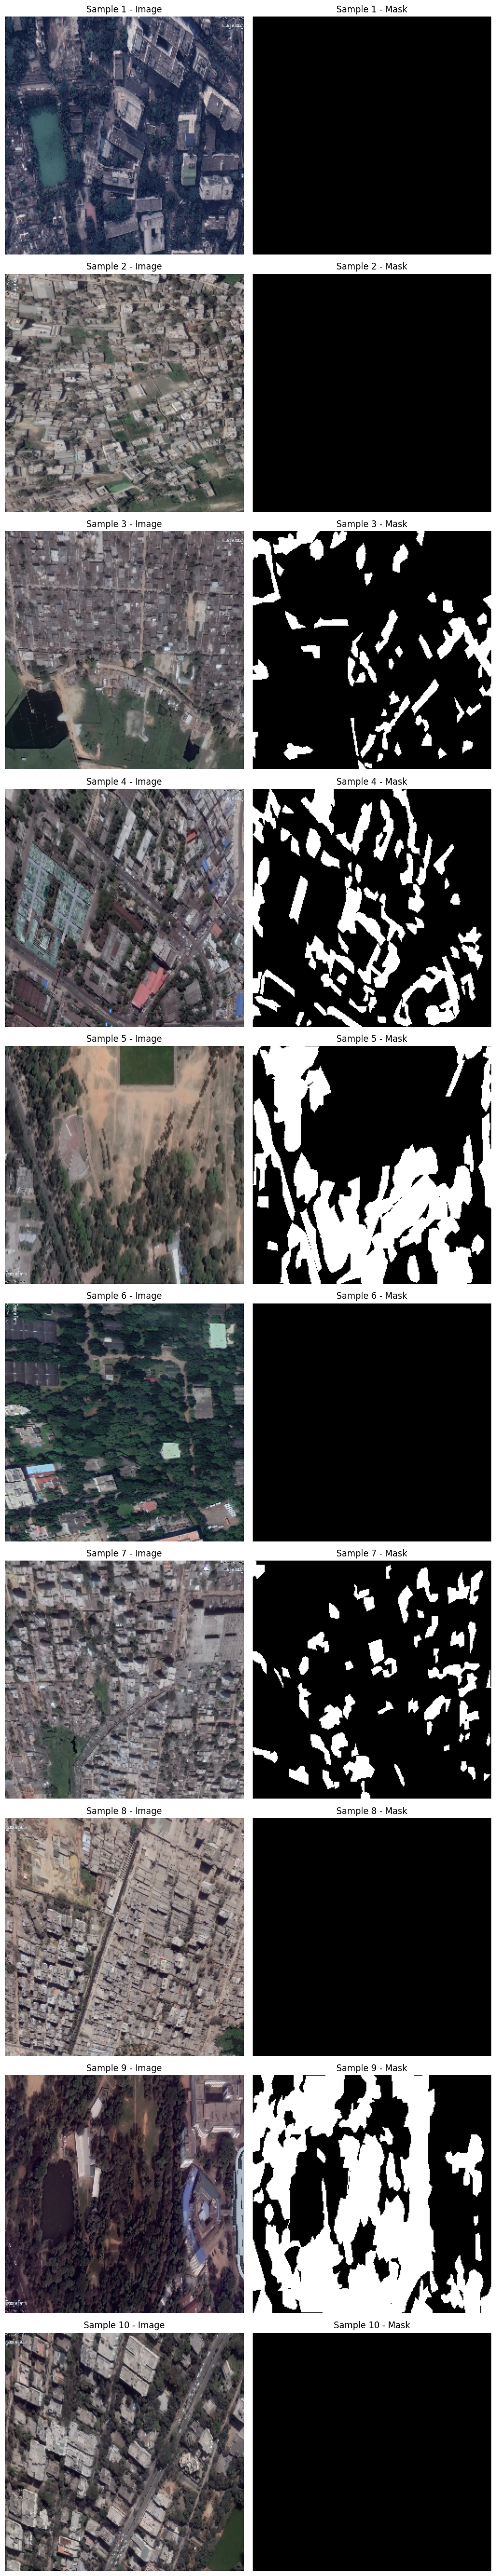

In [2]:

import matplotlib.pyplot as plt

image_files = glob.glob(os.path.join(DATASET_PATH, "**/Raw/*.jpg"), recursive=True)

check_ds = DeforestationDataset(image_files=image_files, transform=train_transform)

num_samples = 10
plt.figure(figsize=(10, num_samples * 5))

for i in range(num_samples):
    idx = random.randint(0, len(check_ds) - 1)
    image, mask = check_ds[idx]

    img_np = image.permute(1, 2, 0).numpy()
    mask_np = mask.squeeze().numpy()

    img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min())

    plt.subplot(num_samples, 2, i*2 + 1)
    plt.imshow(img_np)
    plt.title(f"Sample {i+1} - Image")
    plt.axis("off")

    plt.subplot(num_samples, 2, i*2 + 2)
    plt.imshow(mask_np, cmap="gray")
    plt.title(f"Sample {i+1} - Mask")
    plt.axis("off")

plt.tight_layout()
plt.show()


In [1]:
import os
import glob
import json
import cv2
import numpy as np
from tqdm import tqdm


DATASET_PATH = "/kaggle/input/new-dataset1/Dataset"

def check_dataset_imbalance(image_files):

    total_pixels = 0
    foreground_pixels = 0 

    print("Analyzing dataset masks to check for class imbalance...")
    
    
    for img_path in tqdm(image_files, desc="Processing Images"):
        json_path = img_path.replace("/Raw/", "/JsonFile/").replace(".jpg", ".json")
        
        
        try:
            image = cv2.imread(img_path)
            if image is None:
                print(f"Warning: Could not read image {img_path}. Skipping.")
                continue
            
            height, width, _ = image.shape
            mask = np.zeros((height, width), dtype=np.uint8)
            
            
            if os.path.exists(json_path):
                with open(json_path, 'r', encoding='utf-8') as f:
                    data = json.load(f)
                
                key = next(iter(data.keys()))
                regions = data[key].get('regions', {})
                for _, region in regions.items():
                    if 'polygon' in region['shape_attributes']['name']:
                        x = region['shape_attributes']['all_points_x']
                        y = region['shape_attributes']['all_points_y']
                        if x and y:
                            cv2.fillPoly(mask, [np.column_stack((x, y)).astype(np.int32)], 255)
            
            
            total_pixels += mask.size
            foreground_pixels += np.sum(mask == 255)

        except Exception as e:
            print(f"Error processing {img_path}: {e}")

    
    if total_pixels == 0:
        print("No pixels were processed. Please check the dataset path and files.")
        return

    background_pixels = total_pixels - foreground_pixels
    
    percent_foreground = (foreground_pixels / total_pixels) * 100
    percent_background = (background_pixels / total_pixels) * 100

    print("\n" + "="*40)
    print("      Dataset Imbalance Analysis")
    print("="*40)
    print(f"Total Pixels Analyzed: {total_pixels:,}")
    print(f"Foreground (Deforested) Pixels: {foreground_pixels:,}")
    print(f"Background Pixels: {background_pixels:,}")
    print("-"*40)
    print(f"Percentage of Foreground (Deforested): {percent_foreground:.4f}%")
    print(f"Percentage of Background: {percent_background:.4f}%")
    print("="*40)
    
    if percent_foreground < 10:
        print("\n Result: The dataset is highly imbalanced.")
    elif percent_foreground < 30:
        print("\n Result: The dataset is moderately imbalanced.")
    else:
        print("\n Result: The dataset is relatively balanced.")


if __name__ == "__main__":
    
    all_image_files = sorted(glob.glob(os.path.join(DATASET_PATH, "**/Raw/*.jpg"), recursive=True))
    
    if not all_image_files:
        print(f"Error: No images found at the specified path: {DATASET_PATH}")
    else:
        check_dataset_imbalance(all_image_files)

Analyzing dataset masks to check for class imbalance...


Processing Images:   3%|▎         | 56/1800 [00:02<01:08, 25.45it/s]

Error processing /kaggle/input/new-dataset1/Dataset/2010/Raw/2010DhakaCantonment (22).jpg: 


Processing Images:  71%|███████   | 1270/1800 [00:46<00:18, 28.42it/s]

Error processing /kaggle/input/new-dataset1/Dataset/2019/Raw/2019Airport (5).jpg: 


...

Error processing /kaggle/input/new-dataset1/Dataset/2020/Raw/2020Airport (5).jpg: 


Processing Images:  87%|████████▋ | 1565/1800 [00:57<00:08, 27.39it/s]

Error processing /kaggle/input/new-dataset1/Dataset/2020/Raw/2020Khilkhet (5).jpg: 


Processing Images: 100%|██████████| 1800/1800 [01:06<00:00, 27.18it/s]


      Dataset Imbalance Analysis
Total Pixels Analyzed: 3,722,112,000
Foreground (Deforested) Pixels: 402,340,415
Background Pixels: 3,319,771,585
----------------------------------------
Percentage of Foreground (Deforested): 10.8095%
Percentage of Background: 89.1905%

💡 Result: The dataset is moderately imbalanced.


In [9]:
def validate_and_print_metrics(loader, model, device="cuda"):
    model.eval()
    
    all_preds_flat = []
    all_labels_flat = []

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            preds = torch.sigmoid(model(x))
            
            preds_binary = (preds > 0.5).cpu().numpy().astype(np.uint8)
            labels_binary = y.cpu().numpy().astype(np.uint8)
            
            all_preds_flat.extend(preds_binary.flatten())
            all_labels_flat.extend(labels_binary.flatten())

    all_preds_flat = np.array(all_preds_flat)
    all_labels_flat = np.array(all_labels_flat)

    accuracy = np.mean(all_preds_flat == all_labels_flat) * 100
    precision = precision_score(all_labels_flat, all_preds_flat, zero_division=0)
    recall = recall_score(all_labels_flat, all_preds_flat, zero_division=0)
    f1 = f1_score(all_labels_flat, all_preds_flat, zero_division=0)
    
    intersection = (all_preds_flat * all_labels_flat).sum()
    total_pixels = all_preds_flat.sum() + all_labels_flat.sum()
    dice = (2. * intersection) / (total_pixels + 1e-8)
    union = total_pixels - intersection
    iou = intersection / (union + 1e-8)

    print(f"[Validation] Acc: {accuracy:.2f}% | Dice: {dice:.4f} | IoU: {iou:.4f} | F1: {f1:.4f} | Prec: {precision:.4f} | Rec: {recall:.4f}")
    
    model.train()
    return dice, iou



In [10]:
    all_files = sorted(glob.glob(os.path.join(DATASET_PATH, "**/Raw/*.jpg"), recursive=True))
    train_size=int(0.8*len(all_files)); val_size=len(all_files)-train_size
    train_indices, val_indices = torch.utils.data.random_split(range(len(all_files)), [train_size, val_size], generator=torch.Generator().manual_seed(42))
    
    train_files = [all_files[i] for i in train_indices.indices]
    val_files = [all_files[i] for i in val_indices.indices]
    
    train_ds = DeforestationDataset(train_files, transform=train_transform)
    val_ds = DeforestationDataset(val_files, transform=val_transform)
    
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, num_workers=2, pin_memory=True, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, num_workers=2, pin_memory=True, shuffle=False)

NameError: name 'DATASET_PATH' is not defined

In [ ]:


class UNet(nn.Module):
    def __init__(self, n_class=1):
        super().__init__()
        self.e1 = ConvBlock(3, 64); self.pool1 = nn.MaxPool2d(2, 2)
        self.e2 = ConvBlock(64, 128); self.pool2 = nn.MaxPool2d(2, 2)
        self.e3 = ConvBlock(128, 256); self.pool3 = nn.MaxPool2d(2, 2)
        self.e4 = ConvBlock(256, 512); self.pool4 = nn.MaxPool2d(2, 2)
        self.bottleneck = ConvBlock(512, 1024)
        self.upconv4 = nn.ConvTranspose2d(1024, 512, 2, 2); self.d4 = ConvBlock(1024, 512)
        self.upconv3 = nn.ConvTranspose2d(512, 256, 2, 2); self.d3 = ConvBlock(512, 256)
        self.upconv2 = nn.ConvTranspose2d(256, 128, 2, 2); self.d2 = ConvBlock(256, 128)
        self.upconv1 = nn.ConvTranspose2d(128, 64, 2, 2); self.d1 = ConvBlock(128, 64)
        self.outconv = nn.Conv2d(64, n_class, 1)
    def forward(self, x):
        xe1=self.e1(x); xp1=self.pool1(xe1); xe2=self.e2(xp1); xp2=self.pool2(xe2)
        xe3=self.e3(xp2); xp3=self.pool3(xe3); xe4=self.e4(xp3); xp4=self.pool4(xe4)
        b = self.bottleneck(xp4)
        du4=self.upconv4(b); cat4=torch.cat((du4,xe4),dim=1); dd4=self.d4(cat4)
        du3=self.upconv3(dd4); cat3=torch.cat((du3,xe3),dim=1); dd3=self.d3(cat3)
        du2=self.upconv2(dd3); cat2=torch.cat((du2,xe2),dim=1); dd2=self.d2(cat2)
        du1=self.upconv1(dd2); cat1=torch.cat((du1,xe1),dim=1); dd1=self.d1(cat1)
        return self.outconv(dd1)

def main_unet():
    print("--- Training Standard U-Net ---")
    model = UNet(n_class=1).to(DEVICE)
    model_save_path = "/kaggle/working/best_unet_model.pth"
    loss_fn = DiceBCELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
    history, _ = train_and_validate(model, train_loader, val_loader, optimizer, loss_fn, EPOCHS_STANDARD, model_save_path)
    np.save("/kaggle/working/unet_history.npy", history)
    print("\n U-Net training completed!")


class AttentionUNet(nn.Module):
    def __init__(self, n_class=1):
        super().__init__()
        self.e1 = ConvBlock(3, 64); self.pool1 = nn.MaxPool2d(2, 2)
        self.e2 = ConvBlock(64, 128); self.pool2 = nn.MaxPool2d(2, 2)
        self.e3 = ConvBlock(128, 256); self.pool3 = nn.MaxPool2d(2, 2)
        self.e4 = ConvBlock(256, 512); self.pool4 = nn.MaxPool2d(2, 2)
        self.bottleneck = ConvBlock(512, 1024)
        self.upconv4 = nn.ConvTranspose2d(1024, 512, 2, 2); self.att4 = AttentionGate(512, 512, 256); self.d4 = ConvBlock(1024, 512)
        self.upconv3 = nn.ConvTranspose2d(512, 256, 2, 2); self.att3 = AttentionGate(256, 256, 128); self.d3 = ConvBlock(512, 256)
        self.upconv2 = nn.ConvTranspose2d(256, 128, 2, 2); self.att2 = AttentionGate(128, 128, 64); self.d2 = ConvBlock(256, 128)
        self.upconv1 = nn.ConvTranspose2d(128, 64, 2, 2); self.att1 = AttentionGate(64, 64, 32); self.d1 = ConvBlock(128, 64)
        self.outconv = nn.Conv2d(64, n_class, 1)
    def forward(self, x):
        xe1=self.e1(x); xp1=self.pool1(xe1); xe2=self.e2(xp1); xp2=self.pool2(xe2)
        xe3=self.e3(xp2); xp3=self.pool3(xe3); xe4=self.e4(xp3); xp4=self.pool4(xe4)
        b = self.bottleneck(xp4)
        du4=self.upconv4(b); ax4=self.att4(g=du4,x=xe4); cat4=torch.cat((du4,ax4),dim=1); dd4=self.d4(cat4)
        du3=self.upconv3(dd4); ax3=self.att3(g=du3,x=xe3); cat3=torch.cat((du3,ax3),dim=1); dd3=self.d3(cat3)
        du2=self.upconv2(dd3); ax2=self.att2(g=du2,x=xe2); cat2=torch.cat((du2,ax2),dim=1); dd2=self.d2(cat2)
        du1=self.upconv1(dd2); ax1=self.att1(g=du1,x=xe1); cat1=torch.cat((du1,ax1),dim=1); dd1=self.d1(cat1)
        return self.outconv(dd1)

def main_attention_unet():
    print("--- Training Attention U-Net ---")
    model = AttentionUNet(n_class=1).to(DEVICE)
    model_save_path = "/kaggle/working/best_att_unet_model.pth"
    loss_fn = DiceBCELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
    history, _ = train_and_validate(model, train_loader, val_loader, optimizer, loss_fn, EPOCHS_STANDARD, model_save_path)
    np.save("/kaggle/working/att_unet_history.npy", history)
    print("\n Attention U-Net training completed!")


class ResNetAttentionUNet(nn.Module):
    def __init__(self, n_class=1, freeze_encoder=True):
        super().__init__()
        
        resnet = models.resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)
        if freeze_encoder:
            for param in resnet.parameters():
                param.requires_grad = False
            print("ResNet50 Encoder layers frozen.")
        
        self.encoder_init = nn.Sequential(resnet.conv1, resnet.bn1, resnet.relu)
        self.pool = resnet.maxpool; self.encoder1 = resnet.layer1; self.encoder2 = resnet.layer2
        self.encoder3 = resnet.layer3; self.encoder4 = resnet.layer4
        self.bottleneck = ConvBlock(2048, 1024)
        self.upconv4 = nn.ConvTranspose2d(1024, 512, 2, 2); self.att4 = AttentionGate(512, 1024, 512); self.d4 = ConvBlock(512 + 1024, 512)
        self.upconv3 = nn.ConvTranspose2d(512, 256, 2, 2); self.att3 = AttentionGate(256, 512, 256); self.d3 = ConvBlock(256 + 512, 256)
        self.upconv2 = nn.ConvTranspose2d(256, 128, 2, 2); self.att2 = AttentionGate(128, 256, 128); self.d2 = ConvBlock(128 + 256, 128)
        self.upconv1 = nn.ConvTranspose2d(128, 64, 2, 2); self.att1 = AttentionGate(64, 64, 64); self.d1 = ConvBlock(64 + 64, 64)
        self.upconv0 = nn.ConvTranspose2d(64, 32, 2, 2); self.final_conv = ConvBlock(32, 32)
        self.outconv = nn.Conv2d(32, n_class, 1)

    def forward(self, x):
        x_init = self.encoder_init(x); xp = self.pool(x_init); xe1 = self.encoder1(xp)
        xe2 = self.encoder2(xe1); xe3 = self.encoder3(xe2); xe4 = self.encoder4(xe3)
        b = self.bottleneck(xe4)
        du4 = self.upconv4(b); ax4 = self.att4(g=du4, x=xe3); dd4 = self.d4(torch.cat([du4, ax4], dim=1))
        du3 = self.upconv3(dd4); ax3 = self.att3(g=du3, x=xe2); dd3 = self.d3(torch.cat([du3, ax3], dim=1))
        du2 = self.upconv2(dd3); ax2 = self.att2(g=du2, x=xe1); dd2 = self.d2(torch.cat([du2, ax2], dim=1))
        du1 = self.upconv1(dd2); ax1 = self.att1(g=du1, x=x_init); dd1 = self.d1(torch.cat([du1, ax1], dim=1))
        du0 = self.upconv0(dd1); dd0 = self.final_conv(du0)
        return self.outconv(dd0)

    def unfreeze_encoder(self, unfreeze_layers=['layer4']):
        if 'layer4' in unfreeze_layers:
            print("Unfreezing ResNet encoder layer 4...")
            for param in self.encoder4.parameters():
                param.requires_grad = True
        if 'layer3' in unfreeze_layers:
            print("Unfreezing ResNet encoder layer 3...")
            for param in self.encoder3.parameters():
                param.requires_grad = True
                
def main_resnet_attention_unet():
    print("--- Training ResNet50 + Attention U-Net with Two-Stage Fine-tuning ---")
    
    model = ResNetAttentionUNet(n_class=1, freeze_encoder=True).to(DEVICE)
    loss_fn = DiceBCELoss()
    optimizer_stage1 = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
    frozen_path = "/kaggle/working/best_resnet_att_unet_frozen.pth"
    history1, model = train_and_validate(model, train_loader, val_loader, optimizer_stage1, loss_fn, EPOCHS_FROZEN, frozen_path)

    print("\n--- Stage 2: Fine-tuning with more layers ---")
    
    model.unfreeze_encoder(unfreeze_layers=['layer3', 'layer4'])
    
    decoder_params = [p for n, p in model.named_parameters() if p.requires_grad and 'encoder' not in n]
    
    optimizer_stage2 = torch.optim.Adam([
        {'params': decoder_params, 'lr': FINE_TUNE_LR},
        {'params': model.encoder4.parameters(), 'lr': FINE_TUNE_LR / 5}, # layer4 এর জন্য 5 গুণ কম
        {'params': model.encoder3.parameters(), 'lr': FINE_TUNE_LR / 10} # layer3 এর জন্য 10 গুণ কম
    ])
    
    finetune_path = "/kaggle/working/best_resnet_att_unet_finetuned.pth"

    best_dice_stage1 = max(history1['val_dice']) if history1['val_dice'] else -1.0
    
    full_history, _ = train_and_validate(
        model, train_loader, val_loader, optimizer_stage2, 
        loss_fn, len(history1['train_loss']) + EPOCHS_FINETUNE, finetune_path,
        start_epoch=len(history1['train_loss']),
        best_dice=best_dice_stage1,
        history=history1
    )
    
    np.save("/kaggle/working/resnet_history.npy", full_history)
    print("\n✅ ResNet-Attention U-Net training completed!")

if __name__ == "__main__":
    resnet_history = main_resnet_attention_unet()

if __name__ == "__main__":
    main_resnet_attention_unet()
    main_unet()
    main_attention_unet()
    
    # pass

--- Training ResNet50 + Attention U-Net with Two-Stage Fine-tuning ---

--- Stage 1: Training with Frozen Encoder ---
ResNet50 Encoder layers frozen.


/tmp/ipykernel_36/3725997227.py:111: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()



--- Epoch 1/100 ---


Training: 100%|██████████| 90/90 [00:26<00:00,  3.46it/s, loss=0.621]


Validation => Loss: 0.5366, Dice Score: 0.4883
=> Best model saved with Dice Score: 0.4883

--- Epoch 2/100 ---


...

Training: 100%|██████████| 90/90 [00:40<00:00,  2.20it/s, loss=0.271]


Validation => Loss: 0.2676, Dice Score: 0.6952

--- Epoch 222/300 ---


Training: 100%|██████████| 90/90 [00:40<00:00,  2.22it/s, loss=0.247]


Validation => Loss: 0.2644, Dice Score: 0.6947

--- Epoch 223/300 ---


Training:   7%|▋         | 6/90 [00:03<00:40,  2.10it/s, loss=0.249]

In [7]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score
import seaborn as sns
import torch
from torch.utils.data import DataLoader
from tqdm import tqdm


def evaluate_model_on_test_set(model_class, model_path, test_loader, device="cuda"):
    model = model_class(n_class=1).to(device)

    # checkpoint load
    checkpoint = torch.load(model_path, map_location=device, weights_only=False)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()

    model_name = model.__class__.__name__
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in tqdm(test_loader, desc=f"Evaluating {model_name}"):
            images, labels = images.to(device), labels.to(device)
            preds = torch.sigmoid(model(images))
            preds_binary = (preds > 0.5).cpu().numpy().astype(np.uint8).flatten()
            labels_binary = labels.cpu().numpy().astype(np.uint8).flatten()
            all_preds.extend(preds_binary)
            all_labels.extend(labels_binary)

    
    precision = precision_score(all_labels, all_preds, zero_division=0)
    recall = recall_score(all_labels, all_preds, zero_division=0)
    f1 = f1_score(all_labels, all_preds, zero_division=0)
    intersection = (np.array(all_preds) * np.array(all_labels)).sum()
    dice = (2 * intersection) / (np.sum(all_preds) + np.sum(all_labels) + 1e-8)
    iou = intersection / (np.sum(all_preds) + np.sum(all_labels) - intersection + 1e-8)

    print(f"\n--- Metrics for {model_name} ---")
    print(f"Dice Score: {dice:.4f}, IoU: {iou:.4f}, F1 Score: {f1:.4f}, "
          f"Precision: {precision:.4f}, Recall: {recall:.4f}")

    #
    cm = confusion_matrix(all_labels, all_preds)
    cm_normalized = confusion_matrix(all_labels, all_preds, normalize='true')

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle(f'Confusion Matrix for {model_name}', fontsize=16)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['BG', 'Deforested'], yticklabels=['BG', 'Deforested'], ax=axes[0])
    axes[0].set_title('Pixel Counts')
    axes[0].set_xlabel('Predicted Label')
    axes[0].set_ylabel('True Label')

    sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Oranges',
                xticklabels=['BG', 'Deforested'], yticklabels=['BG', 'Deforested'], ax=axes[1])
    axes[1].set_title('Normalized by True Label (Recall)')
    axes[1].set_xlabel('Predicted Label')
    axes[1].set_ylabel('True Label')

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

    metrics = {
        'Model': model_name,
        'Dice Score': dice,
        'IoU': iou,
        'F1 Score': f1,
        'Precision': precision,
        'Recall': recall
    }
    return metrics, cm



def visualize_model_comparison(sample_image, sample_mask, models_to_compare, device="cuda"):
    fig, axes = plt.subplots(1, len(models_to_compare) + 2, figsize=(20, 5))

    
    img_np = sample_image.cpu().permute(1, 2, 0).numpy()
    mean = np.array([0.485, 0.456, 0.406]); std = np.array([0.229, 0.224, 0.225])
    img_np = std * img_np + mean
    img_np = np.clip(img_np, 0, 1)

    axes[0].imshow(img_np); axes[0].set_title("Original Image"); axes[0].axis("off")
    axes[1].imshow(sample_mask.squeeze(), cmap="gray"); axes[1].set_title("Ground Truth"); axes[1].axis("off")

    input_tensor = sample_image.unsqueeze(0).to(device)

    
    for i, (name, model) in enumerate(models_to_compare.items()):
        model.eval()
        with torch.no_grad():
            logits = model(input_tensor)
            pred_mask = (torch.sigmoid(logits) > 0.5).cpu().squeeze().numpy().astype(np.uint8)
        axes[i+2].imshow(pred_mask, cmap='gray')
        axes[i+2].set_title(f"Predicted: {name}")
        axes[i+2].axis("off")

    plt.tight_layout()
    plt.show()


def analyze_error_map(sample_mask, models_to_compare, sample_image_tensor, device="cuda"):
    fig, axes = plt.subplots(1, len(models_to_compare), figsize=(15, 5))
    fig.suptitle("Error Analysis Map (FP: Red, FN: Blue)", fontsize=16)

    gt = sample_mask.squeeze().numpy()

    for i, (name, model) in enumerate(models_to_compare.items()):
        model.eval()
        with torch.no_grad():
            pred = (torch.sigmoid(model(sample_image_tensor.unsqueeze(0).to(device))) > 0.5).cpu().squeeze().numpy()

        error_map = np.zeros((*gt.shape, 4), dtype=np.uint8)
        error_map[np.where(gt == 1)] = [255, 255, 255, 255]  
        error_map[np.where((gt == 0) & (pred == 1))] = [255, 0, 0, 255]  
        error_map[np.where((gt == 1) & (pred == 0))] = [0, 0, 255, 255]  

        axes[i].imshow(error_map)
        axes[i].set_title(name)
        axes[i].axis("off")

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()



if __name__ == "__main__":
    all_metrics = []

    # --- Test split বানানো ---
    all_files = sorted(glob.glob(os.path.join(DATASET_PATH, "**/Raw/*.jpg"), recursive=True))
    train_size = int(0.8 * len(all_files))
    val_test_size = len(all_files) - train_size
    val_size = test_size = val_test_size // 2
    if val_test_size % 2 != 0:
        test_size += 1

    indices = torch.utils.data.random_split(
        range(len(all_files)),
        [train_size, val_size, test_size],
        generator=torch.Generator().manual_seed(42)
    )[2].indices

    test_files = [all_files[i] for i in indices]
    test_ds = DeforestationDataset(test_files, transform=val_transform)
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

    if os.path.exists("best_unet_model.pth"):
        metrics, cm_unet = evaluate_model_on_test_set(UNet, "best_unet_model.pth", test_loader)
        all_metrics.append(metrics)

    if os.path.exists("best_att_unet_model.pth"):
        metrics, cm_att = evaluate_model_on_test_set(AttentionUNet, "best_att_unet_model.pth", test_loader)
        all_metrics.append(metrics)

    if os.path.exists("best_resnet_att_unet_finetuned.pth"):
        metrics, cm_resnet = evaluate_model_on_test_set(ResNetAttentionUNet, "best_resnet_att_unet_finetuned.pth", test_loader)
        all_metrics.append(metrics)

    # --- Summary Table ---
    if all_metrics:
        df_results = pd.DataFrame(all_metrics).set_index('Model')
        print("\n" + "="*60)
        print("          Final Performance Summary Table (with IoU)")
        print("="*60)
        print(df_results.to_string(float_format="%.4f"))
        print("="*60 + "\n")

    # --- Qualitative comparison ---
    print("\n--- Qualitative Comparison on a Random Test Sample ---")
    models_to_compare = {}

    if os.path.exists("best_unet_model.pth"):
        unet_model = UNet(n_class=1).to(DEVICE)
        checkpoint = torch.load("best_unet_model.pth", map_location=DEVICE, weights_only=False)
        unet_model.load_state_dict(checkpoint['model_state_dict'])
        models_to_compare["U-Net"] = unet_model

    if os.path.exists("best_att_unet_model.pth"):
        att_model = AttentionUNet(n_class=1).to(DEVICE)
        checkpoint = torch.load("best_att_unet_model.pth", map_location=DEVICE, weights_only=False)
        att_model.load_state_dict(checkpoint['model_state_dict'])
        models_to_compare["Attention U-Net"] = att_model

    if os.path.exists("best_resnet_att_unet_finetuned.pth"):
        resnet_model = ResNetAttentionUNet(n_class=1).to(DEVICE)
        checkpoint = torch.load("best_resnet_att_unet_finetuned.pth", map_location=DEVICE, weights_only=False)
        resnet_model.load_state_dict(checkpoint['model_state_dict'])
        models_to_compare["ResNet-Att-UNet"] = resnet_model

    if models_to_compare:
        sample_image, sample_mask = next(iter(test_loader))
        visualize_model_comparison(sample_image[0], sample_mask[0], models_to_compare)
        print("\n--- Error Map Analysis for the same sample ---")
        analyze_error_map(sample_mask[0], models_to_compare, sample_image[0])
    else:
        print("No trained models found for qualitative comparison.")


NameError: name 'DATASET_PATH' is not defined